# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 10: Preparación de Datos para Modelos de Machine Learning.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns
import sys
import os
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s10")
src_path = os.path.join(absolute_path, "src", "s10")
figure_path = os.path.join(absolute_path, "figuras", "s10")
sys.path.insert(0, src_path)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

El objetivo de esta sesión es poder realizar todo el preprocesamiento de la base de datos previo al modelamiento.

1. Dataset
2. EDA
3. Definición del Target, Train, Test y Validación
4. Tratamiento de valores faltantes
5. Tratamiento de outliers
6. Encoding de variables categóricas
7. Escalado y transformaciones
8. Manejo de Desbalanceo de clases
9. Pipeline de procesamiento


# 🗂️ **1. Selección y Carga del Dataset**

En línea a tener un dataset bastante enriquecido para las futuras sesiones, se ha elaborado un **dataset semi-sintético** construido sobre la estructura del dataset *Home Credit Default Risk* de Kaggle, al que añadiremos ruido, valores faltantes realistas y variables adicionales relevantes para crédito bancario.

- **Dataset semi-sintético**: Base de Kaggle enriquecida con ruido realista | Realismo + control pedagógico

**Razón principal:** Los datos de Kaggle típicos (Give Me Some Credit, German Credit, etc.) son demasiado pequeños o demasiado limpios. El dataset semi-sintético nos permite:
- Tener variables numéricas y categóricas ricas
- Controlar el nivel de desbalance de clases (~7–10% de defaults)
- Tener valores faltantes en lugares realistas (ingresos no declarados, historial corto)
- Garantizar que los modelos en sesiones 11–18 produzcan resultados pedagógicamente interesantes (no perfectos, pero sí interpretables)

> **Give Me Some Credit** (Kaggle): https://www.kaggle.com/c/GiveMeSomeCredit

📑 **Diccionario de Datos: Crédito Semi-Sintético**

| N° | Variable | Descripción | Categoría |
| :---: | :--- | :--- | :---: |
| **1** | `DEFAULT` | **Variable Objetivo (Target)**: {0: al día, 1: incumplimiento en 12 meses}. | 🎯 |
| **2** | `ID_CLIENTE` | Identificador único alfanumérico del cliente (ej. CLI000001). | 🆔 |
| **3** | `EDAD` | Edad del cliente en años (rango de 18 a 75). | 👤 |
| **4** | `GENERO` | Género del solicitante: **M** (Masculino) o **F** (Femenino). | 👫 |
| **5** | `ESTADO_CIVIL` | Situación civil: Soltero, Casado, Divorciado o Viudo. | 💍 |
| **6** | `NIVEL_EDUCATIVO` | Máximo nivel alcanzado: Secundaria, Técnico, Universitario o Postgrado. | 🎓 |
| **7** | `NUM_DEPENDIENTES` | Número de personas que dependen económicamente del titular (0 a 4). | 👨‍👩‍👧‍👦 |
| **8** | `TIPO_EMPLEO` | Situación laboral: Dependiente, Independiente, Empresario, Jubilado o Sin empleo. | 💼 |
| **9** | `INGRESO_MENSUAL` | Ingresos mensuales netos (incluye ~8% de valores nulos). | 💵 |
| **10** | `ANTIGUEDAD_LABORAL` | Años de experiencia en el empleo actual (incluye ~5% de valores nulos). | ⏳ |
| **11** | `TIPO_CREDITO` | Categoría del préstamo: Consumo, Hipotecario, Vehicular o Empresarial. | 🏷️ |
| **12** | `MONTO_CREDITO` | Monto total del capital solicitado en el préstamo. | 💰 |
| **13** | `PLAZO_MESES` | Tiempo pactado para la devolución del crédito (12 a 120 meses). | 📅 |
| **14** | `TASA_INTERES` | Tasa de interés anual aplicada al producto crediticio. | 📈 |
| **15** | `NUM_CREDITOS_PREVIOS` | Cantidad de créditos registrados anteriormente en el sistema. | 📂 |
| **16** | `DIAS_MORA_MAX` | Máximo de días de atraso histórico registrado (incluye ~6% de valores nulos). | ⚠️ |
| **17** | `RATIO_UTILIZACION` | Porcentaje de uso de líneas de crédito (0 a 1). | 💳 |
| **18** | `TIPO_VIVIENDA` | Régimen de vivienda: Propia, Arrendada, Familiar o Hipotecada. | 🏠 |
| **19** | `RATIO_LTV` | *Loan to Value*: Porcentaje del valor del bien financiado (solo Hipotecarios). | 🏠📉 |

In [2]:
df = pd.read_csv(os.path.join(data_path, "credit_data_raw.csv"))
df.sort_values(by=['FECHA_ALTA', 'ID_CLIENTE'], inplace=True)
print(f'✅ Dataset creado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Tasa de default: {df["DEFAULT"].mean():.2%}')
df.head()

✅ Dataset creado: 30,000 filas × 20 columnas
   Tasa de default: 22.46%


,ID_CLIENTE,FECHA_ALTA,EDAD,GENERO,ESTADO_CIVIL,NIVEL_EDUCATIVO,NUM_DEPENDIENTES,TIPO_EMPLEO,INGRESO_MENSUAL,ANTIGUEDAD_LABORAL,TIPO_CREDITO,MONTO_CREDITO,PLAZO_MESES,TASA_INTERES,NUM_CREDITOS_PREVIOS,DIAS_MORA_MAX,RATIO_UTILIZACION,TIPO_VIVIENDA,RATIO_LTV,DEFAULT
55,CLI000056,2025-01-01,52,M,Soltero,Postgrado,2,Independiente,NaN,10.0,Consumo,6503.0,84,17.93,3,30.0,0.1972,Arrendada,NaN,0
533,CLI000534,2025-01-01,28,M,Casado,Técnico,1,Dependiente,3152.0,1.7,Hipotecario,5988.0,84,18.88,2,NaN,0.1604,Propia,0.642,0
1856,CLI001857,2025-01-01,57,F,Soltero,Universitario,0,Dependiente,3181.0,0.5,Hipotecario,9853.0,48,21.63,5,0.0,0.2798,Familiar,0.821,1
2829,CLI002830,2025-01-01,37,M,Casado,Técnico,0,Independiente,1233.0,12.4,Hipotecario,22521.0,36,11.02,2,90.0,0.3468,Propia,0.622,0
3486,CLI003487,2025-01-01,58,F,Casado,Técnico,0,Empresario,1470.0,8.3,Consumo,13057.0,24,16.96,4,0.0,0.1068,Arrendada,NaN,0


# 🔍 **2. Exploratory Data Analysis (EDA)**

**Recordatorio de la Sesión 3:** En la Parte 1 del curso realizamos un EDA exhaustivo. 

Aquí hacemos una EDA enfocada en detectar problemas específicos para ML: tipos de datos, cardinalidad, distribuciones extremas y concentración de valores.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 55 to 29779
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_CLIENTE            30000 non-null  object 
 1   FECHA_ALTA            30000 non-null  object 
 2   EDAD                  30000 non-null  int64  
 3   GENERO                30000 non-null  object 
 4   ESTADO_CIVIL          30000 non-null  object 
 5   NIVEL_EDUCATIVO       30000 non-null  object 
 6   NUM_DEPENDIENTES      30000 non-null  int64  
 7   TIPO_EMPLEO           30000 non-null  object 
 8   INGRESO_MENSUAL       27586 non-null  float64
 9   ANTIGUEDAD_LABORAL    28484 non-null  float64
 10  TIPO_CREDITO          30000 non-null  object 
 11  MONTO_CREDITO         30000 non-null  float64
 12  PLAZO_MESES           30000 non-null  int64  
 13  TASA_INTERES          30000 non-null  float64
 14  NUM_CREDITOS_PREVIOS  30000 non-null  int64  
 15  DIAS_MORA_MAX         2

In [4]:
df.describe()

,EDAD,NUM_DEPENDIENTES,INGRESO_MENSUAL,ANTIGUEDAD_LABORAL,MONTO_CREDITO,PLAZO_MESES,TASA_INTERES,NUM_CREDITOS_PREVIOS,DIAS_MORA_MAX,RATIO_UTILIZACION,RATIO_LTV,DEFAULT
count,30000.000000,30000.000000,27586.000000,28484.000000,30000.000000,30000.000000,30000.000000,30000.000000,28253.000000,28868.000000,9051.000000,30000.000000
mean,41.559400,1.316267,2937.613355,7.037688,21969.146133,43.031600,18.005620,3.009367,27.761654,0.285619,0.724816,0.224567
std,10.810607,1.152311,2061.474550,6.874020,27574.382151,22.956719,5.929103,1.736811,43.747878,0.160258,0.130196,0.417304
min,18.000000,0.000000,500.000000,0.000000,1000.000000,12.000000,5.000000,0.000000,0.000000,0.001100,0.500000,0.000000
25%,34.000000,0.000000,1476.000000,2.100000,6815.000000,24.000000,13.910000,2.000000,0.000000,0.161500,0.614000,0.000000
50%,42.000000,1.000000,2382.000000,4.900000,13267.000000,36.000000,17.960000,3.000000,0.000000,0.264350,0.724000,0.000000
75%,49.000000,2.000000,3766.000000,9.800000,26173.750000,60.000000,22.010000,4.000000,30.000000,0.389400,0.837000,0.000000
max,75.000000,4.000000,25908.000000,40.000000,300000.000000,120.000000,40.960000,13.000000,180.000000,0.912600,0.950000,1.000000


array([[<Axes: title={'center': 'EDAD'}>,
        <Axes: title={'center': 'NUM_DEPENDIENTES'}>,
        <Axes: title={'center': 'INGRESO_MENSUAL'}>],
       [<Axes: title={'center': 'ANTIGUEDAD_LABORAL'}>,
        <Axes: title={'center': 'MONTO_CREDITO'}>,
        <Axes: title={'center': 'PLAZO_MESES'}>],
       [<Axes: title={'center': 'TASA_INTERES'}>,
        <Axes: title={'center': 'NUM_CREDITOS_PREVIOS'}>,
        <Axes: title={'center': 'DIAS_MORA_MAX'}>],
       [<Axes: title={'center': 'RATIO_UTILIZACION'}>,
        <Axes: title={'center': 'RATIO_LTV'}>,
        <Axes: title={'center': 'DEFAULT'}>]], dtype=object)

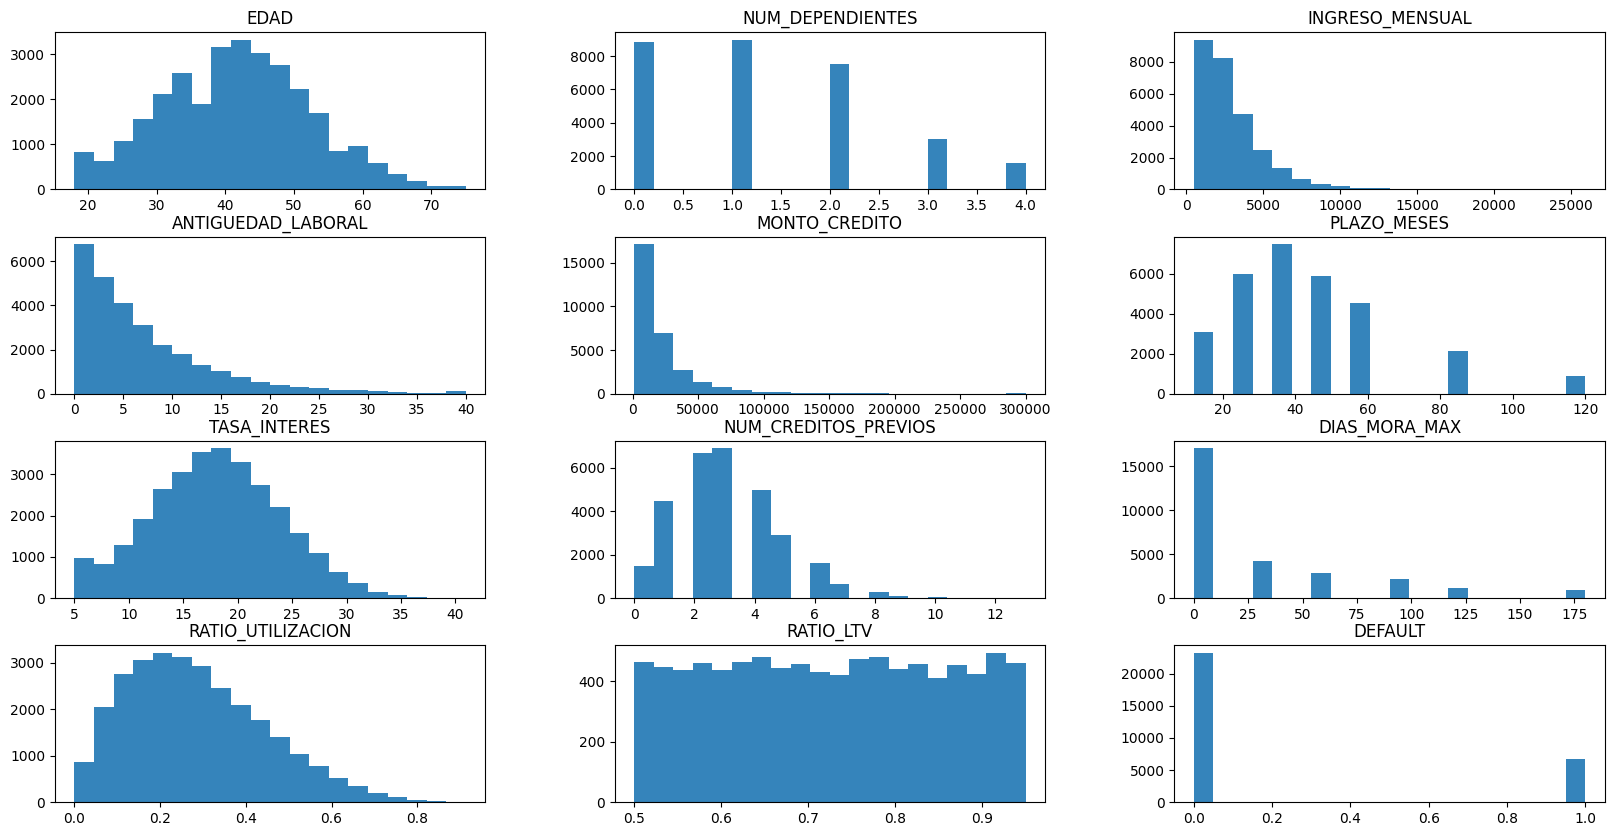

In [5]:
df.hist(bins=20, figsize=(20,10), alpha=0.9, grid=False)

In [6]:
df.isnull().mean().sort_values(ascending=False).to_frame(name='% Missing').T*100

,RATIO_LTV,INGRESO_MENSUAL,DIAS_MORA_MAX,ANTIGUEDAD_LABORAL,RATIO_UTILIZACION,EDAD,FECHA_ALTA,ID_CLIENTE,GENERO,TIPO_EMPLEO,ESTADO_CIVIL,NIVEL_EDUCATIVO,MONTO_CREDITO,TIPO_CREDITO,NUM_DEPENDIENTES,PLAZO_MESES,NUM_CREDITOS_PREVIOS,TASA_INTERES,TIPO_VIVIENDA,DEFAULT
% Missing,69.83,8.046667,5.823333,5.053333,3.773333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


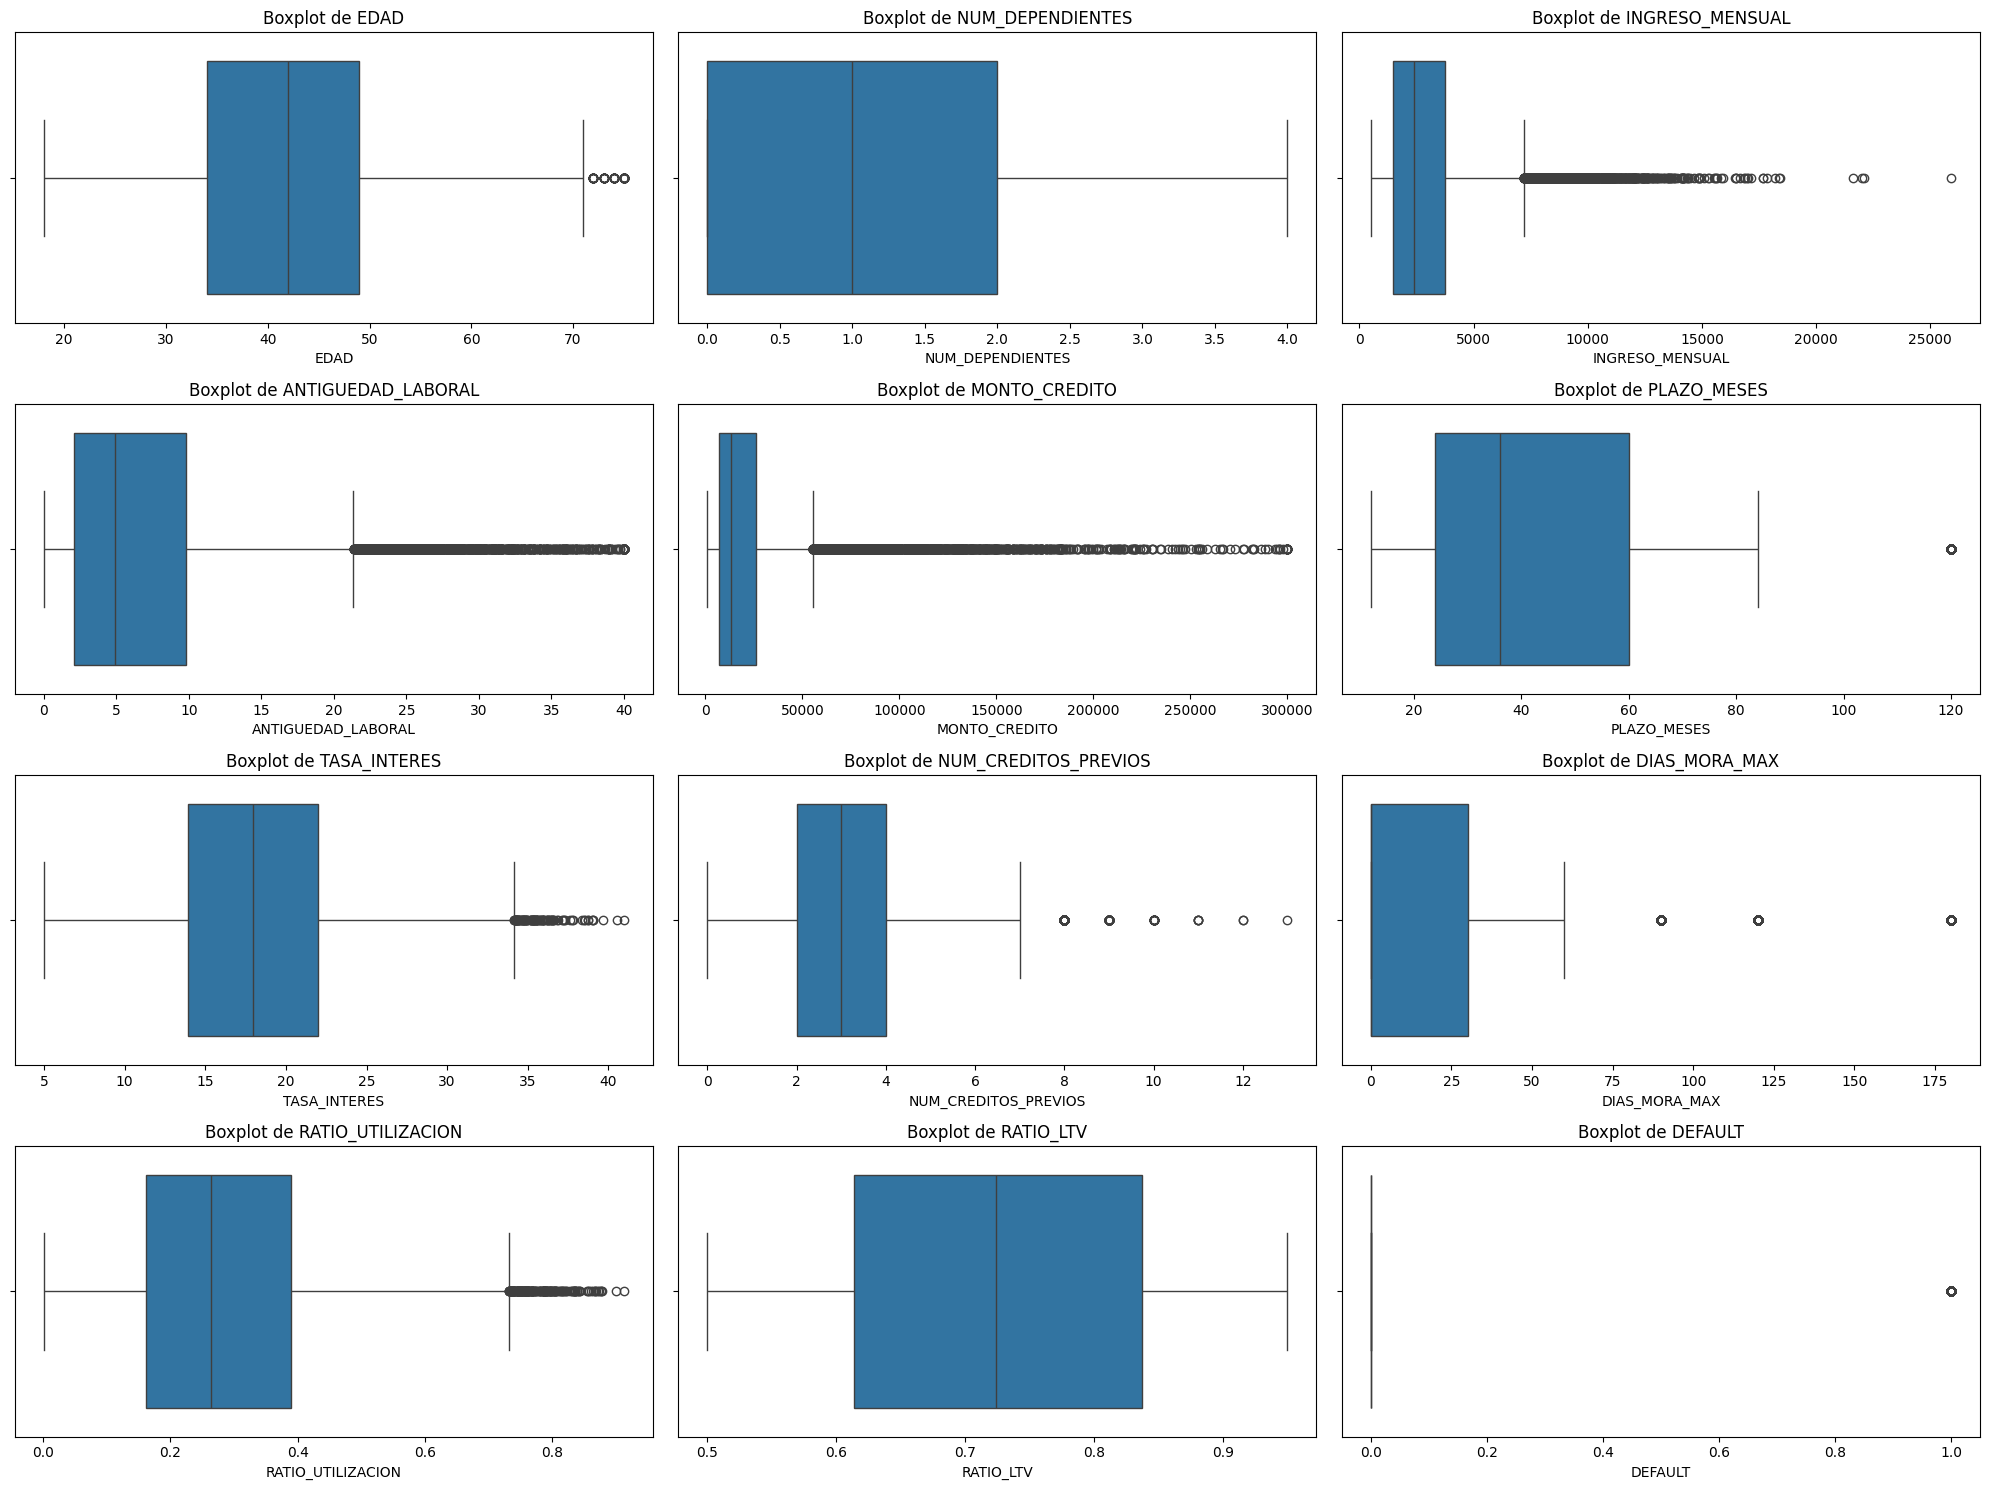

In [7]:
v_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))
for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'Boxplot de {col}')
    ax.grid(False)
plt.tight_layout()
plt.show()

In [8]:
v_cat = df.select_dtypes(include='object').columns.tolist()
v_cat

['ID_CLIENTE',
 'FECHA_ALTA',
 'GENERO',
 'ESTADO_CIVIL',
 'NIVEL_EDUCATIVO',
 'TIPO_EMPLEO',
 'TIPO_CREDITO',
 'TIPO_VIVIENDA']

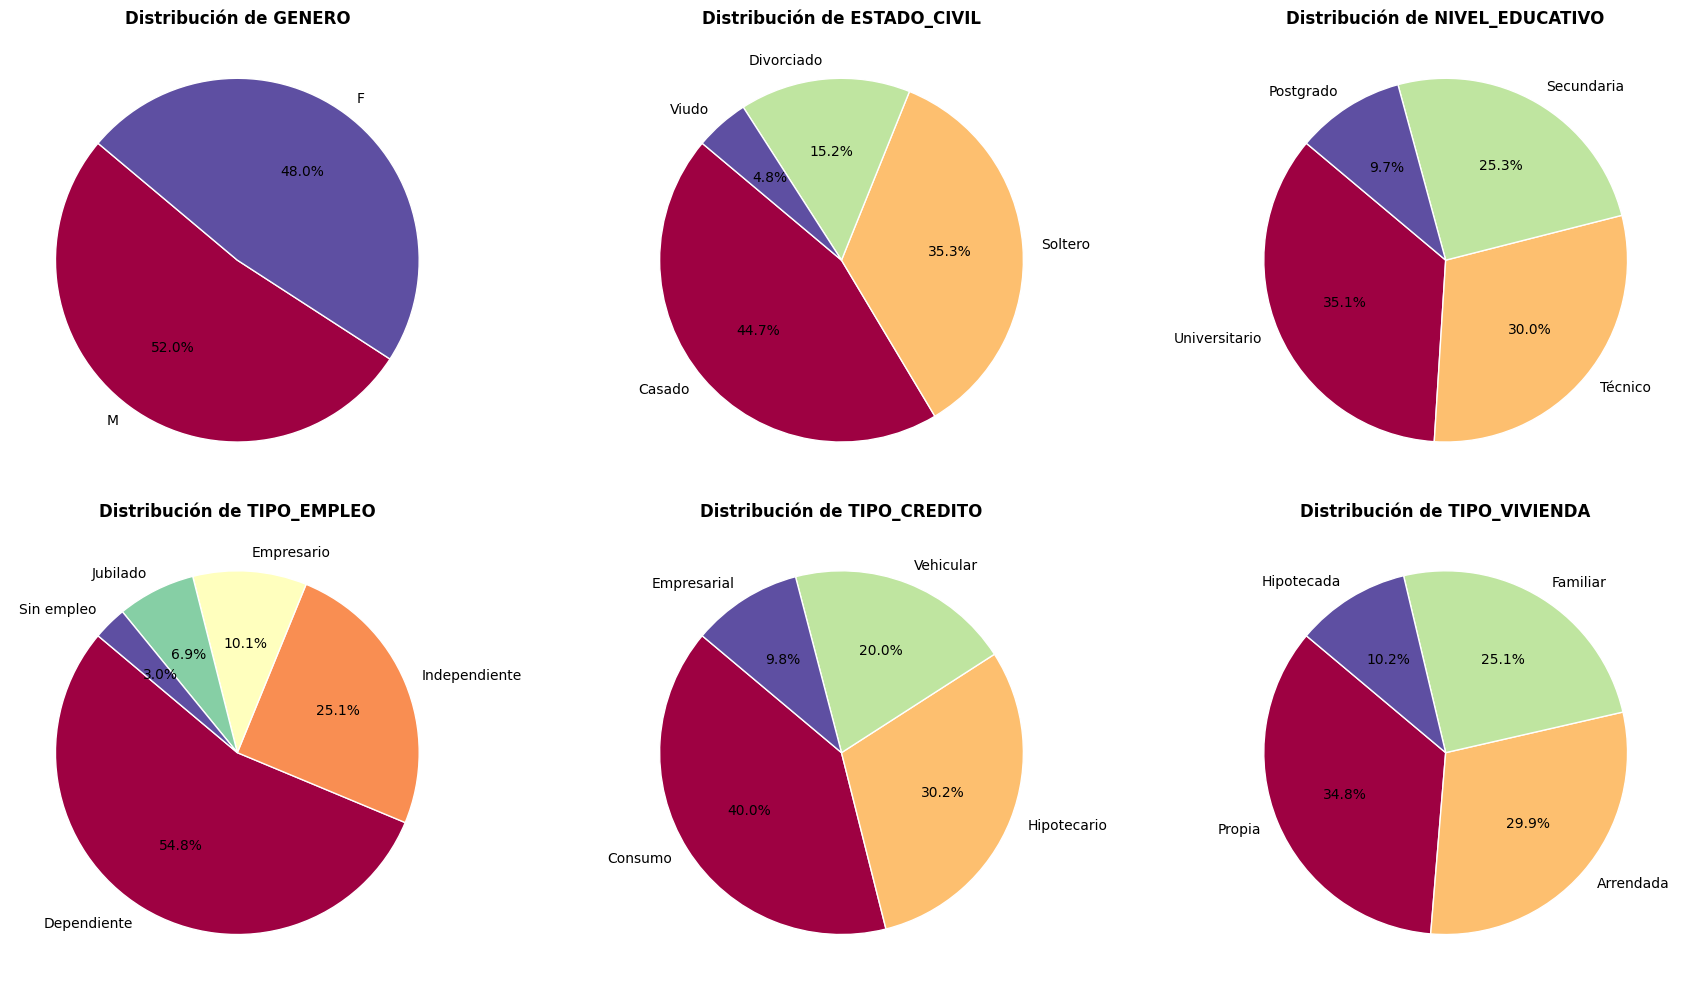

In [9]:
v_cat = df.select_dtypes(include='object').columns.tolist()
v_cat.remove('ID_CLIENTE')
v_cat.remove('FECHA_ALTA')

n_cols = 3
n_rows = (len(v_cat) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(v_cat):
    # 1. Contar las frecuencias de cada categoría
    data_counts = df[col].value_counts()
    
    # 2. Crear el gráfico de pastel en Matplotlib
    axes[i].pie(
        data_counts, 
        labels=data_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Spectral(np.linspace(0, 1, len(data_counts))),
        wedgeprops={'edgecolor': 'white'}
    )
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

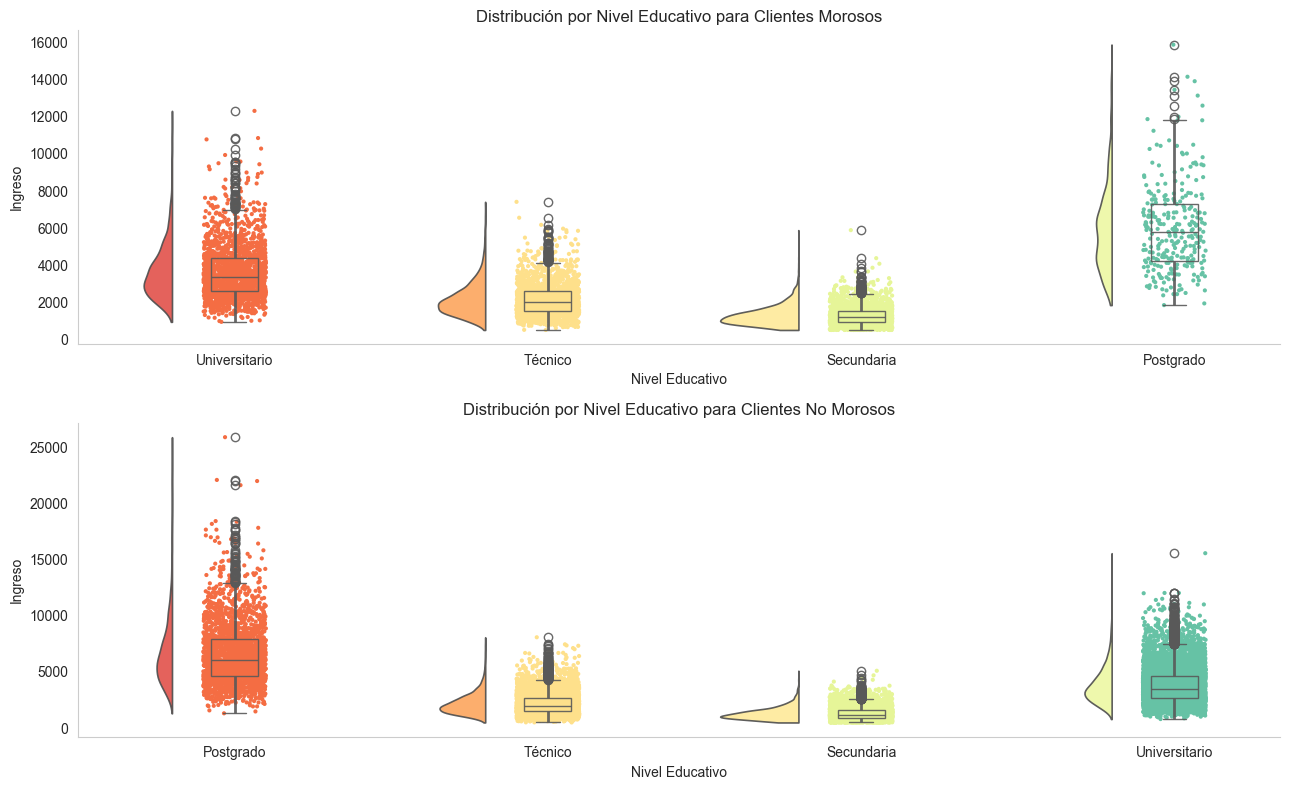

In [10]:
sns.set_style("whitegrid")  # fondo blanco y cuadrícula
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Raincloud plot para 'nivel_educ' y 'ingreso' en el primer subgráfico
pt.RainCloud(x="NIVEL_EDUCATIVO", y="INGRESO_MENSUAL", data=df[df['DEFAULT']==1], # SOLO clientes que default=1 (morosos)
                palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[0],
                alpha=0.9, jitter=True, linewidth=1.2) # transparencia, dispersión y grosor de líneas 
axes[0].set_title("Distribución por Nivel Educativo para Clientes Morosos", fontsize=12)
axes[0].set_xlabel("Nivel Educativo", fontsize=10)
axes[0].set_ylabel("Ingreso", fontsize=10)
axes[0].grid(False)
sns.despine(ax=axes[0])
plt.grid(False)

# Raincloud plot para 'housing_type' y 'deuda_sf' en el segundo subgráfico
pt.RainCloud(x="NIVEL_EDUCATIVO", y="INGRESO_MENSUAL", data=df[df['DEFAULT']==0],
                palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[1],
                alpha=0.9, jitter=True, linewidth=1.2)
axes[1].set_title("Distribución por Nivel Educativo para Clientes No Morosos", fontsize=12)
axes[1].set_xlabel("Nivel Educativo", fontsize=10)
axes[1].set_ylabel("Ingreso", fontsize=10)
axes[1].grid(False)
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

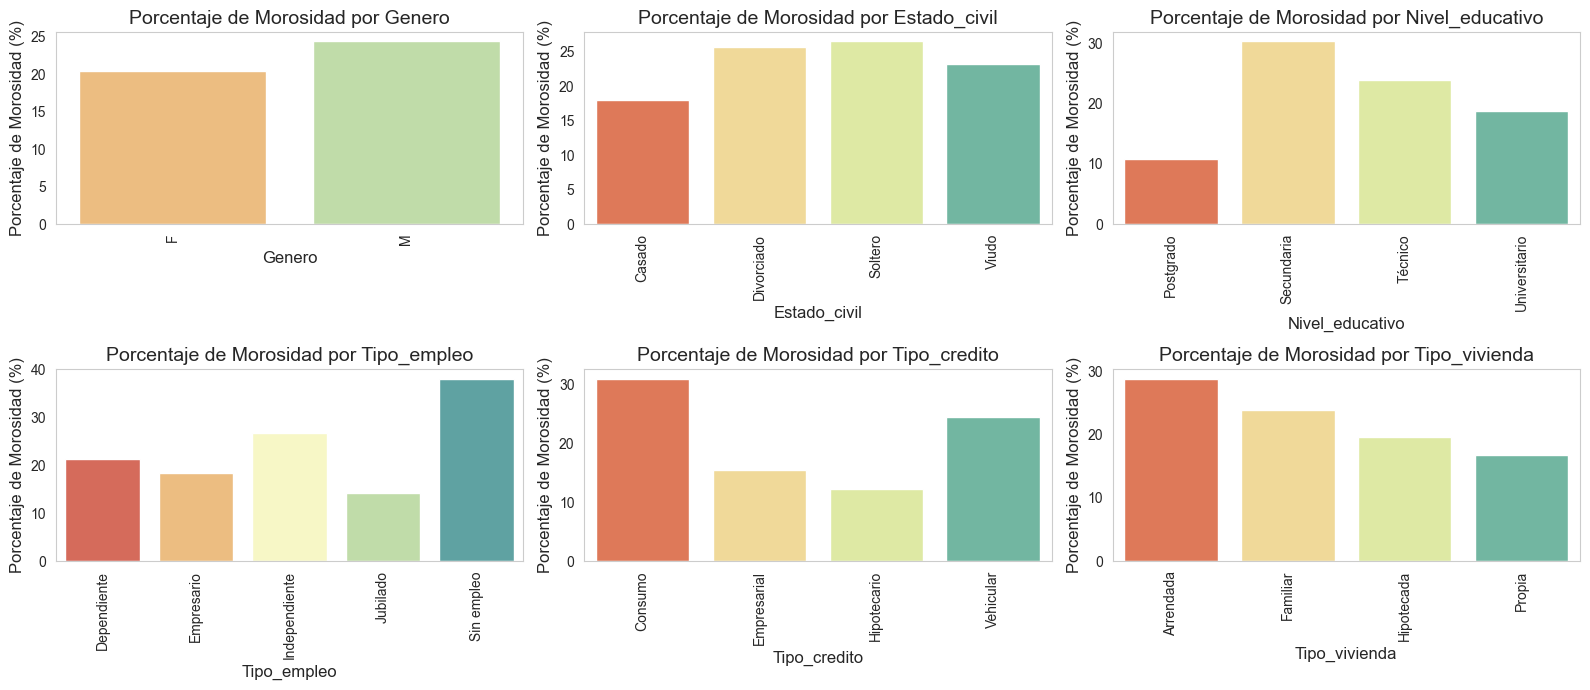

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 7))

for col, ax in zip(v_cat, axes.flatten()): 
    mora_percent = df.groupby(col)['DEFAULT'].mean().reset_index()
    mora_percent['DEFAULT'] *= 100 
    sns.barplot(data=mora_percent, x=col, y='DEFAULT', ax=ax, palette="Spectral")
    ax.set_title(f'Porcentaje de Morosidad por {col.capitalize()}', fontsize=14)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel("Porcentaje de Morosidad (%)", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)
plt.tight_layout()
plt.show()

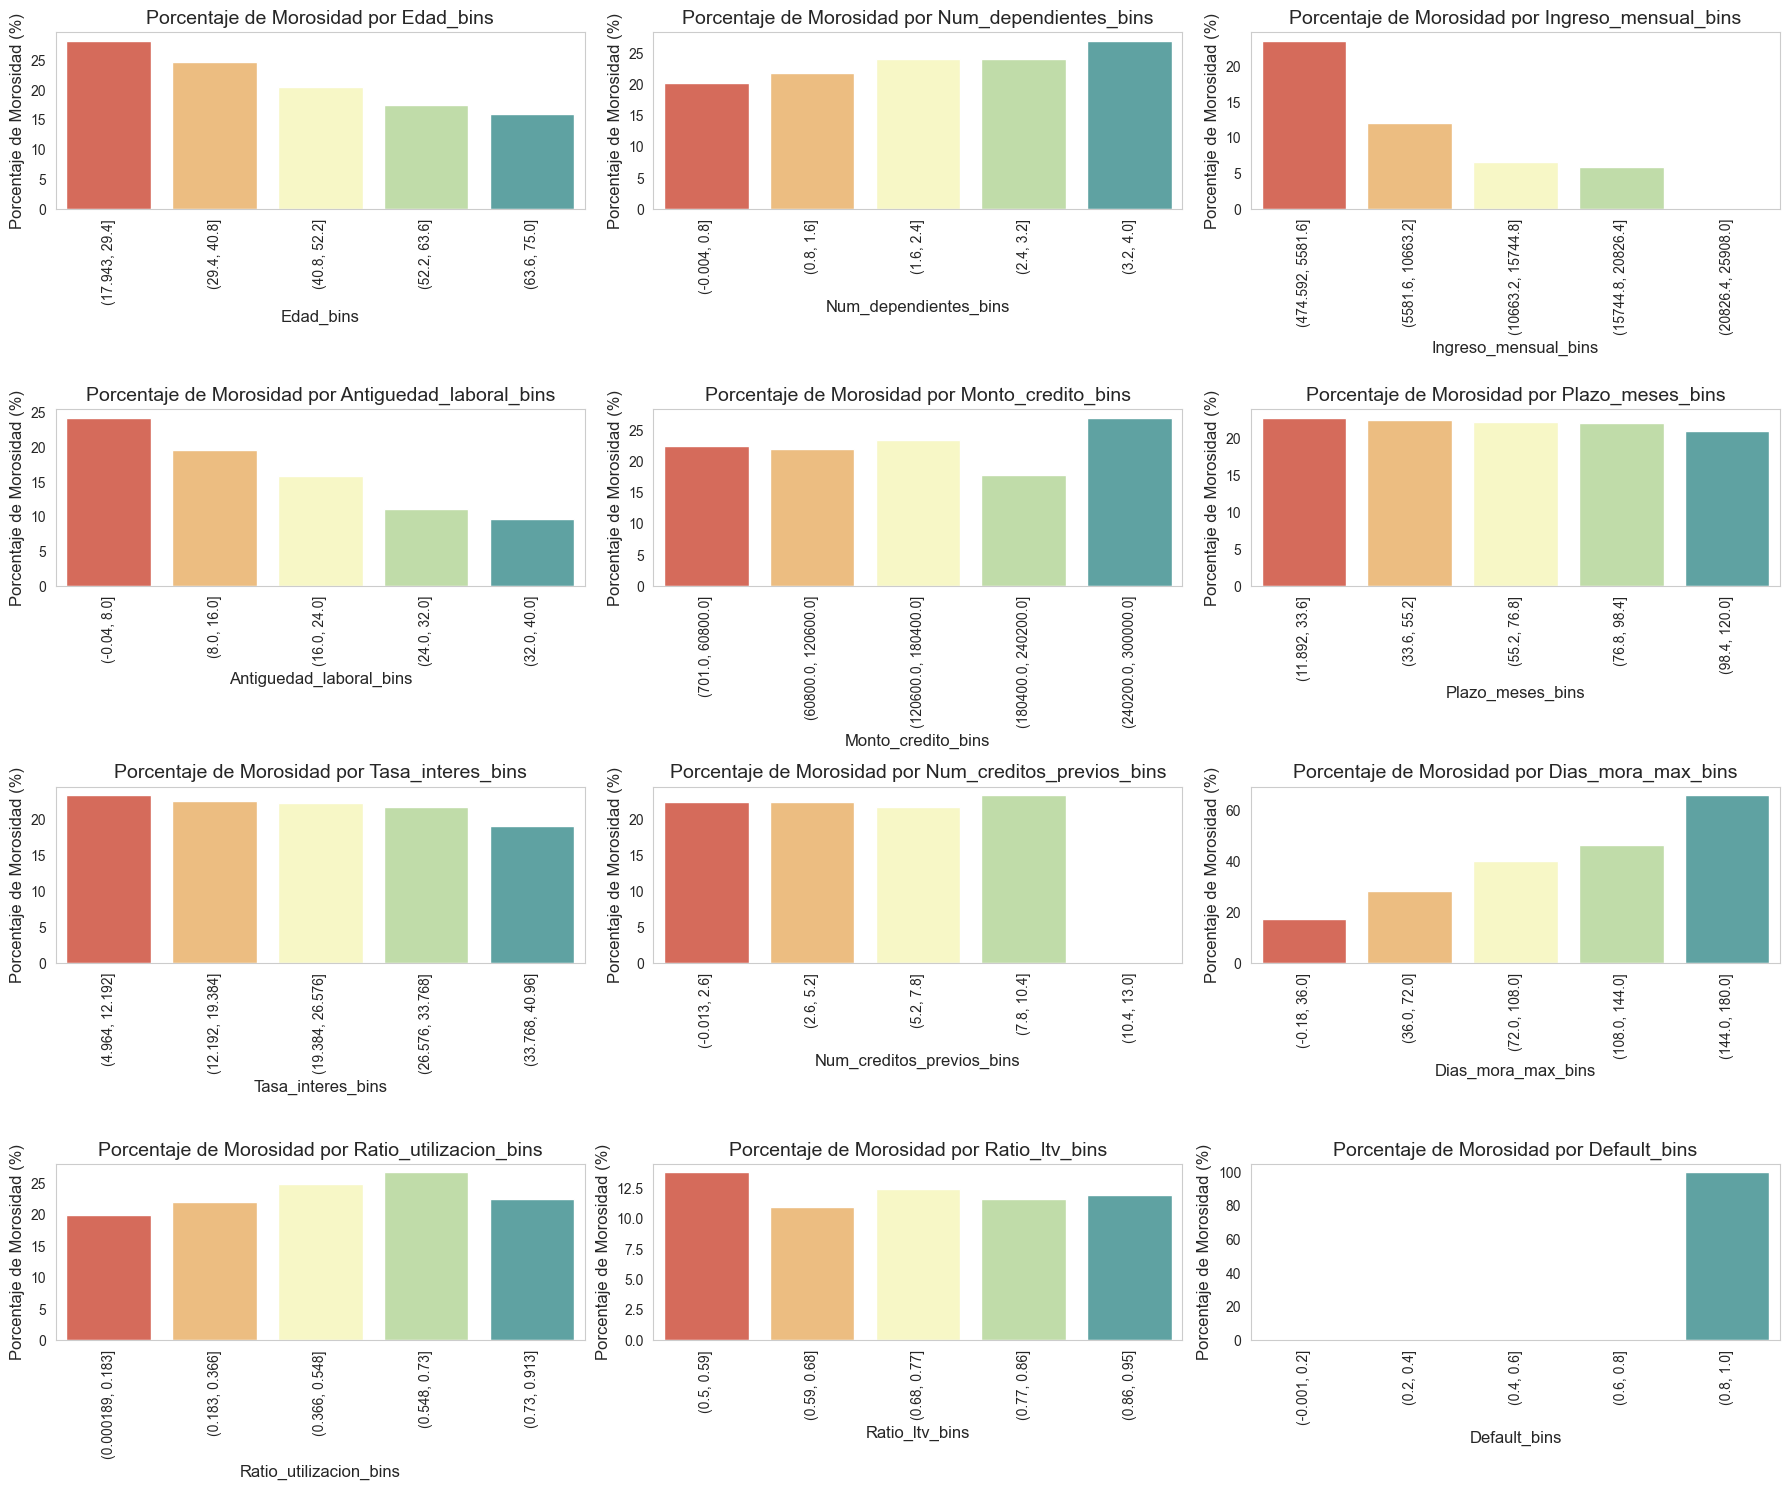

In [12]:
df_copy = df.copy()
var_list = []

for i in v_num:
	df_copy[f'{i}_bins'] = pd.cut(df_copy[i], 5)
	var_list.append(f'{i}_bins')

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 15))
for col, ax in zip(var_list, axes.flatten()): 
    mora_percent = df_copy.groupby(col)['DEFAULT'].mean().reset_index()
    mora_percent['DEFAULT'] *= 100 
    sns.barplot(data=mora_percent, x=col, y='DEFAULT', ax=ax, palette="Spectral")
    ax.set_title(f'Porcentaje de Morosidad por {col.capitalize()}', fontsize=14)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel("Porcentaje de Morosidad (%)", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)

for ax in  axes.flatten()[len(var_list):]:
    ax.set_visible(False)  # o ax.axis('off')
    
plt.tight_layout()
plt.show()

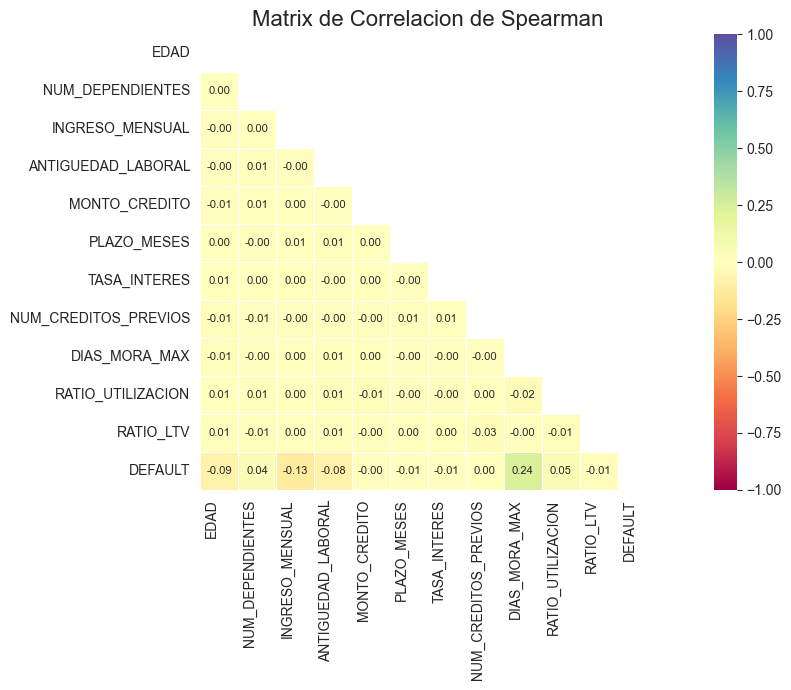

In [13]:
corr = df[v_num].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 7))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion de Spearman", fontsize=16)
plt.tight_layout()
plt.show()

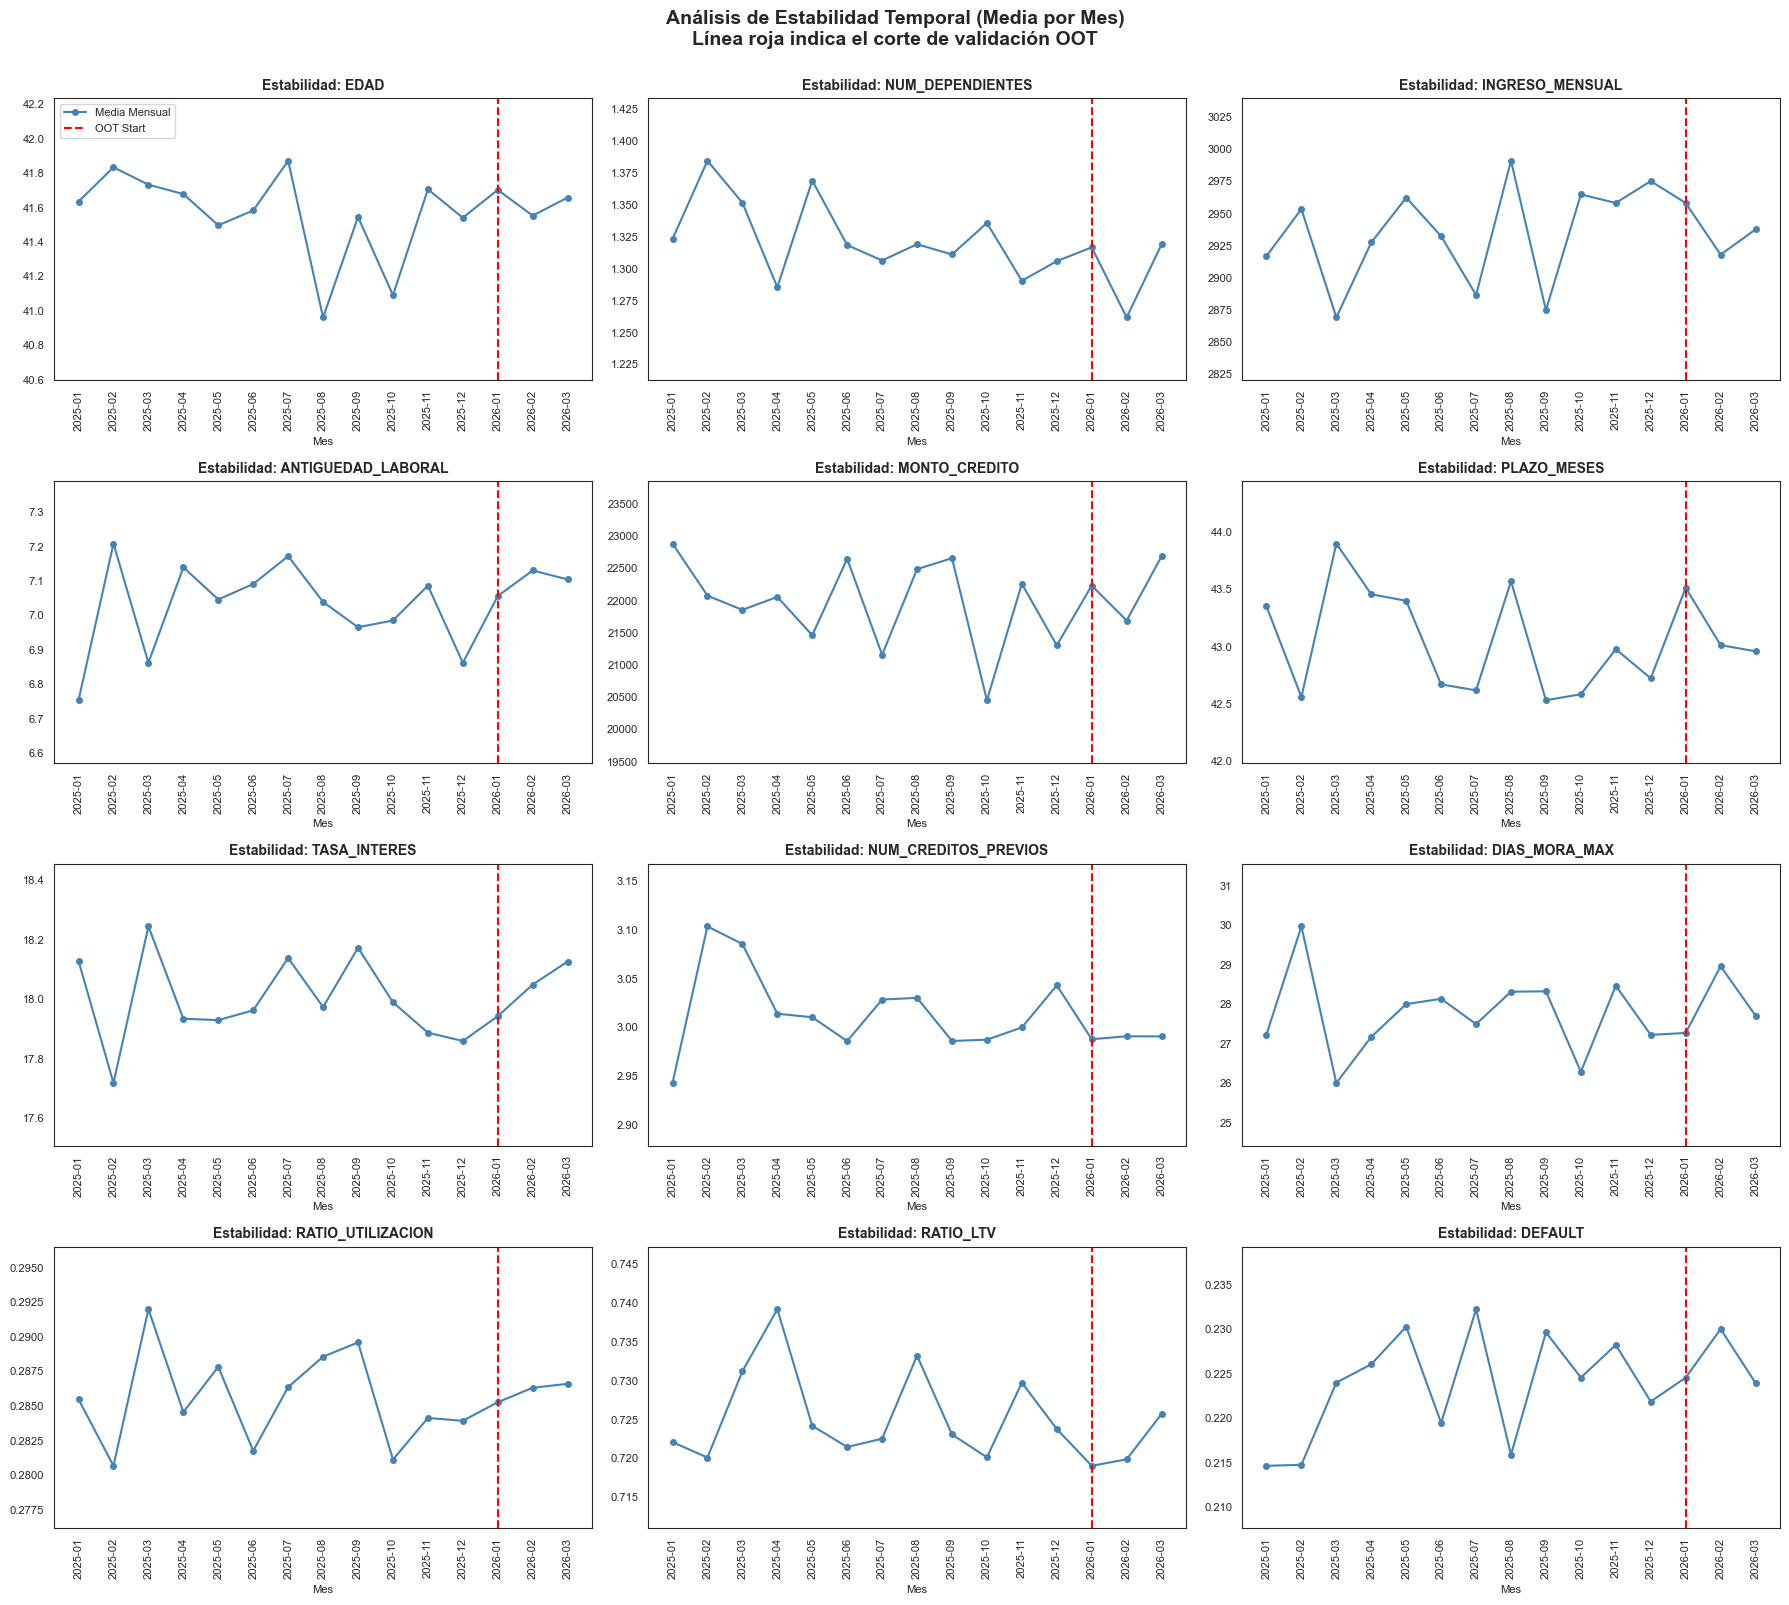

In [14]:
df['FECHA_ALTA'] = pd.to_datetime(df['FECHA_ALTA'], errors='coerce')
df['MES'] = df['FECHA_ALTA'].dt.to_period('M')
df['MES_STR'] = df['MES'].astype(str)

OOT_START_MONTH = pd.to_datetime('2026-01-01').strftime('%Y-%m')

vars_to_plot = v_num 
ncols = 3
nrows = (len(vars_to_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    monthly = df.groupby('MES_STR')[col].mean().sort_index()
    
    ax = axes[i]
    
    ax.plot(monthly.index, monthly.values, marker='o', markersize=4,
            linewidth=1.5, color='steelblue', label='Media Mensual')

    x_pos = list(monthly.index).index(OOT_START_MONTH)
    ax.axvline(x=x_pos, color='red', linestyle='--', linewidth=1.5, label='OOT Start')
    
    y_min = monthly.min()
    y_max = monthly.max()
    margin = (y_max - y_min) * 0.4  # puedes probar 0.3 - 0.7
    
    ax.set_ylim(y_min - margin, y_max + margin)
    
    ax.set_title(f'Estabilidad: {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mes', fontsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.tick_params(axis='y', labelsize=8)
    
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Análisis de Estabilidad Temporal (Media por Mes)\nLínea roja indica el corte de validación OOT', fontsize=14, fontweight='bold', y=1.0)

plt.tight_layout()
plt.show()

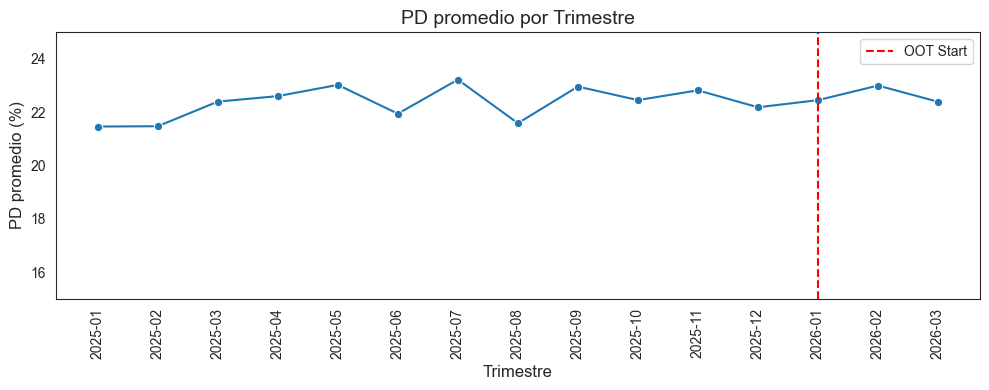

In [15]:
pd_mean = df.groupby('MES_STR', as_index=False)['DEFAULT'].mean()
pd_mean['DEFAULT'] *= 100

plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=pd_mean, x='MES_STR', y='DEFAULT', marker='o')
plt.title("PD promedio por Trimestre", fontsize=14)
plt.xlabel("Trimestre", fontsize=12)
plt.ylabel("PD promedio (%)", fontsize=12)
plt.xticks(rotation=90)

x_pos = pd_mean['MES_STR'].tolist().index(OOT_START_MONTH)
ax.axvline(x=x_pos, color='red', linestyle='--', linewidth=1.5, label='OOT Start')

ax.set_ylim(15, 25)
ax.legend()
plt.tight_layout()
plt.show()

# 🎯 **3. Definición del Target y Horizonte Temporal**

| Concepto | Descripción | Implicación para ML |
|----------|-------------|---------------------|
| **Punto de corte (observation point)** | Fecha en que se observan las características del cliente | Las variables deben estar disponibles *antes* de esta fecha |
| **Ventana de performance** | Período en que se evalúa si hay incumplimiento | Típicamente 12 meses para PD según IFRS 9 |
| **Data leakage** | Usar información futura para predecir | Error crítico: infla métricas artificialmente |
| **Sample selection bias** | Sesgo por selección de la muestra de entrenamiento | Solo vemos los créditos aprobados, no los rechazados |

> 📌 **Regla de oro:** Ninguna variable en X debe contener información que no esté disponible al momento de la solicitud del crédito.

```
──────────────────────────────────────────────────────────────────▶ tiempo
 2025-01-01          2025-11-01      2026-01-01      2026-03-31
     │                    │                │                │
     │◄─── TRAIN (~67%) ─►│◄─ VAL (~13%) ─►│◄── TEST (~20%)►│
```

In [16]:
df.head()

,ID_CLIENTE,FECHA_ALTA,EDAD,GENERO,ESTADO_CIVIL,NIVEL_EDUCATIVO,NUM_DEPENDIENTES,TIPO_EMPLEO,INGRESO_MENSUAL,ANTIGUEDAD_LABORAL,TIPO_CREDITO,MONTO_CREDITO,PLAZO_MESES,TASA_INTERES,NUM_CREDITOS_PREVIOS,DIAS_MORA_MAX,RATIO_UTILIZACION,TIPO_VIVIENDA,RATIO_LTV,DEFAULT,MES,MES_STR
55,CLI000056,2025-01-01,52,M,Soltero,Postgrado,2,Independiente,NaN,10.0,Consumo,6503.0,84,17.93,3,30.0,0.1972,Arrendada,NaN,0,2025-01,2025-01
533,CLI000534,2025-01-01,28,M,Casado,Técnico,1,Dependiente,3152.0,1.7,Hipotecario,5988.0,84,18.88,2,NaN,0.1604,Propia,0.642,0,2025-01,2025-01
1856,CLI001857,2025-01-01,57,F,Soltero,Universitario,0,Dependiente,3181.0,0.5,Hipotecario,9853.0,48,21.63,5,0.0,0.2798,Familiar,0.821,1,2025-01,2025-01
2829,CLI002830,2025-01-01,37,M,Casado,Técnico,0,Independiente,1233.0,12.4,Hipotecario,22521.0,36,11.02,2,90.0,0.3468,Propia,0.622,0,2025-01,2025-01
3486,CLI003487,2025-01-01,58,F,Casado,Técnico,0,Empresario,1470.0,8.3,Consumo,13057.0,24,16.96,4,0.0,0.1068,Arrendada,NaN,0,2025-01,2025-01


In [17]:
VALL_START = pd.to_datetime('2025-11-01').strftime(r'%Y-%m-%d')
OOT_START = pd.to_datetime('2026-01-01').strftime(r'%Y-%m-%d')
drop_cols = ['ID_CLIENTE', 'FECHA_ALTA', 'MES', 'MES_STR', 'MES_STR']

mask_train = df['FECHA_ALTA'] <  VALL_START
mask_val   = (df['FECHA_ALTA'] >= VALL_START) & (df['FECHA_ALTA'] < OOT_START)
mask_test  = df['FECHA_ALTA'] >= OOT_START

train = df[mask_train].copy()
val   = df[mask_val].copy()
oot  = df[mask_test].copy()

X_train = train.drop(columns=drop_cols + ['DEFAULT'])
y_train = train['DEFAULT']
X_val = val.drop(columns=drop_cols + ['DEFAULT'])
y_val = val['DEFAULT']
X_test = oot.drop(columns=drop_cols + ['DEFAULT'])
y_test = oot['DEFAULT']

print(f"Train: {X_train.shape}  | Val: {X_val.shape} | Test (OOT): {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}  | Validation default rate: {y_val.mean():.2%} | " f"Test default rate: {y_test.mean():.2%}")

Train: (17341, 17)  | Val: (4784, 17) | Test (OOT): (7875, 17)
Train default rate: 22.38%  | Validation default rate: 22.49% | Test default rate: 22.60%


# 🩹 **4: Tratamiento de Valores Faltantes**

Estrategias de imputación y cuándo usar cada una

| Método | Cuándo usarlo | Ventajas | Riesgos |
|--------|--------------|----------|---------|
| **Mediana** | Variables numéricas con outliers | Robusto a extremos | Ignora estructura |
| **Media** | Variables numéricas simétricas | Simple | Sensible a outliers |
| **Moda** | Variables categóricas | Simple | Puede introducir sesgo |
| **KNN Imputer** | Datos con estructura de vecindad | Aprovecha correlaciones | Computacionalmente costoso |
| **Indicador de faltante** | Cuando el hecho de faltar es informativo | Preserva información | Agrega dimensionalidad |
| **Eliminar columna** | >70–80% de faltantes | Reduce ruido | Puede perder información |

> 📌 **Criterio para credit scoring:** Si una variable tiene >70% de faltantes, evaluar si eliminarla o si el faltante en sí es un predictor (e.g., sin historial crediticio = cliente nuevo = mayor riesgo).

In [18]:
# ── Estrategia de imputación por variable ─────────────────────────────────────
#
#  LÓGICA GENERAL: el método de imputación no es arbitrario.
#  Depende de DOS preguntas:
#    1. ¿El hecho de que falte el dato es informativo por sí solo?
#       → Si sí: crear IND_*_MISSING antes de imputar
#    2. ¿Qué sabemos del mecanismo que generó el faltante?
#       → Determina el método (mediana, KNN, cero semántico)
#
#  ┌─────────────────────┬───────────────────────┬─────────────────────────────┐
#  │ Variable            │ Mecanismo del faltante│ Estrategia                  │
#  ├─────────────────────┼───────────────────────┼─────────────────────────────┤
#  │ INGRESO_MENSUAL     │ No declarado  (MNAR)  │ IND + KNN (usa edad,        │
#  │                     │ clientes de mayor     │ educación, tipo empleo)     │
#  │                     │ riesgo suelen omitirlo│                             │
#  ├─────────────────────┼───────────────────────┼─────────────────────────────┤
#  │ DIAS_MORA_MAX       │ Sin historial (MCAR*) │ IND + cero semántico        │
#  │                     │ cliente nuevo, no hubo│ (ausencia de mora = 0 días) │
#  │                     │ mora porque no hay    │                             │
#  │                     │ créditos previos      │                             │
#  ├─────────────────────┼──────────────────────┼─────────────────────────────┤
#  │ RATIO_UTILIZACION   │ Sin tarjeta (MAR*)    │ Mediana (no hay señal en el │
#  │                     │ el faltante depende   │ faltante, solo ausencia     │
#  │                     │ del tipo de producto  │ de producto)                │
#  ├─────────────────────┼──────────────────────┼─────────────────────────────┤
#  │ ANTIGUEDAD_LABORAL  │ Empleo reciente (MAR*)│ Cero semántico              │
#  │                     │ nuevo en el trabajo   │ (recién ingresado = 0 años) │
#  ├─────────────────────┼──────────────────────┼─────────────────────────────┤
#  │ RATIO_LTV           │ Estructural: solo     │ Cero (no aplica el ratio    │
#  │                     │ existe en hipotecarios│ para otros tipos de crédito)│
#  └─────────────────────┴──────────────────────┴─────────────────────────────┘
#
#  * MNAR = Missing Not At Random (el faltante está correlacionado con el valor)
#  * MCAR = Missing Completely At Random
#  * MAR  = Missing At Random (el faltante depende de otras variables observadas)

# ── PASO 1: Indicadores de faltante — ANTES de cualquier imputación ───────────
#    Si se crean después, el indicador siempre vale 0 (ya no hay NaN)
X_train['IND_INGRESO_MISSING']   = X_train['INGRESO_MENSUAL'].isnull().astype(int)
X_train['IND_HISTORIAL_MISSING'] = X_train['DIAS_MORA_MAX'].isnull().astype(int)

# ── PASO 2: KNN Imputer para INGRESO_MENSUAL ──────────────────────────────────
#
#  ¿Por qué KNN?
#  Variables auxiliares para el KNN (disponibles, sin NaN, correladas con ingreso): 
#  EDAD, NUM_DEPENDIENTES, NIVEL_EDUCATIVO (ya encoded), TIPO_EMPLEO (ya encoded)
VARS_AUX_KNN = ['INGRESO_MENSUAL', 'ANTIGUEDAD_LABORAL']

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train[VARS_AUX_KNN] = knn_imputer.fit_transform(X_train[VARS_AUX_KNN])

# ── PASO 3: Mediana para RATIO_UTILIZACION ────────────────────────────────────
#    MAR → no hay señal en el faltante → mediana es suficiente
median_util = X_train['RATIO_UTILIZACION'].median()
X_train['RATIO_UTILIZACION'] = X_train['RATIO_UTILIZACION'].fillna(median_util)

# ── PASO 4: Cero semántico ────────────────────────────────────────────────────
#    El valor 0 tiene interpretación de negocio directa en estos tres casos
X_train['DIAS_MORA_MAX']      = X_train['DIAS_MORA_MAX'].fillna(0)       # sin mora = 0
X_train['ANTIGUEDAD_LABORAL'] = X_train['ANTIGUEDAD_LABORAL'].fillna(0)  # recién ingresado = 0
X_train['RATIO_LTV']          = X_train['RATIO_LTV'].fillna(0)           # no hipotecario = 0

# ── Verificación final ────────────────────────────────────────────────────────
remaining = X_train.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print(f'\nImputación completada — sin valores faltantes restantes')
else:
    print(f'\nFaltantes residuales:\n{remaining}')


Imputación completada — sin valores faltantes restantes


# 🔤 **5: Encoding de Variables Categóricas**

Estrategias de encoding en credit scoring ML

| Método | Descripción | Cuándo usarlo | Algoritmos compatibles |
|--------|-------------|---------------|------------------------|
| **One-Hot Encoding (OHE)** | Crea columna binaria por categoría | Variables nominales, pocas categorías (<10) | Regresión Logística, SVM |
| **Label Encoding** | Asigna número entero a cada categoría | Solo para ordinales o árboles | Árboles, Gradient Boosting |
| **Ordinal Encoding** | Asigna orden explícito | Variables con orden natural | Cualquier modelo |
| **Target Encoding** | Reemplaza categoría con media del target | Alta cardinalidad | Gradient Boosting |
| **WOE Encoding** ✅ | Usar el WOE de la Sesión 4 | Credit scoring bancario | Regresión Logística, comparación |
| **Binary Encoding** | Representación binaria | Alta cardinalidad | Árboles |

> 📌 **Decisión del curso:** Para las sesiones de árboles y GBM, usaremos **Label Encoding** (los árboles de scikit-learn no requieren OHE). Para la Regresión Logística de comparación, usaremos **OHE**. Documentaremos ambos enfoques.

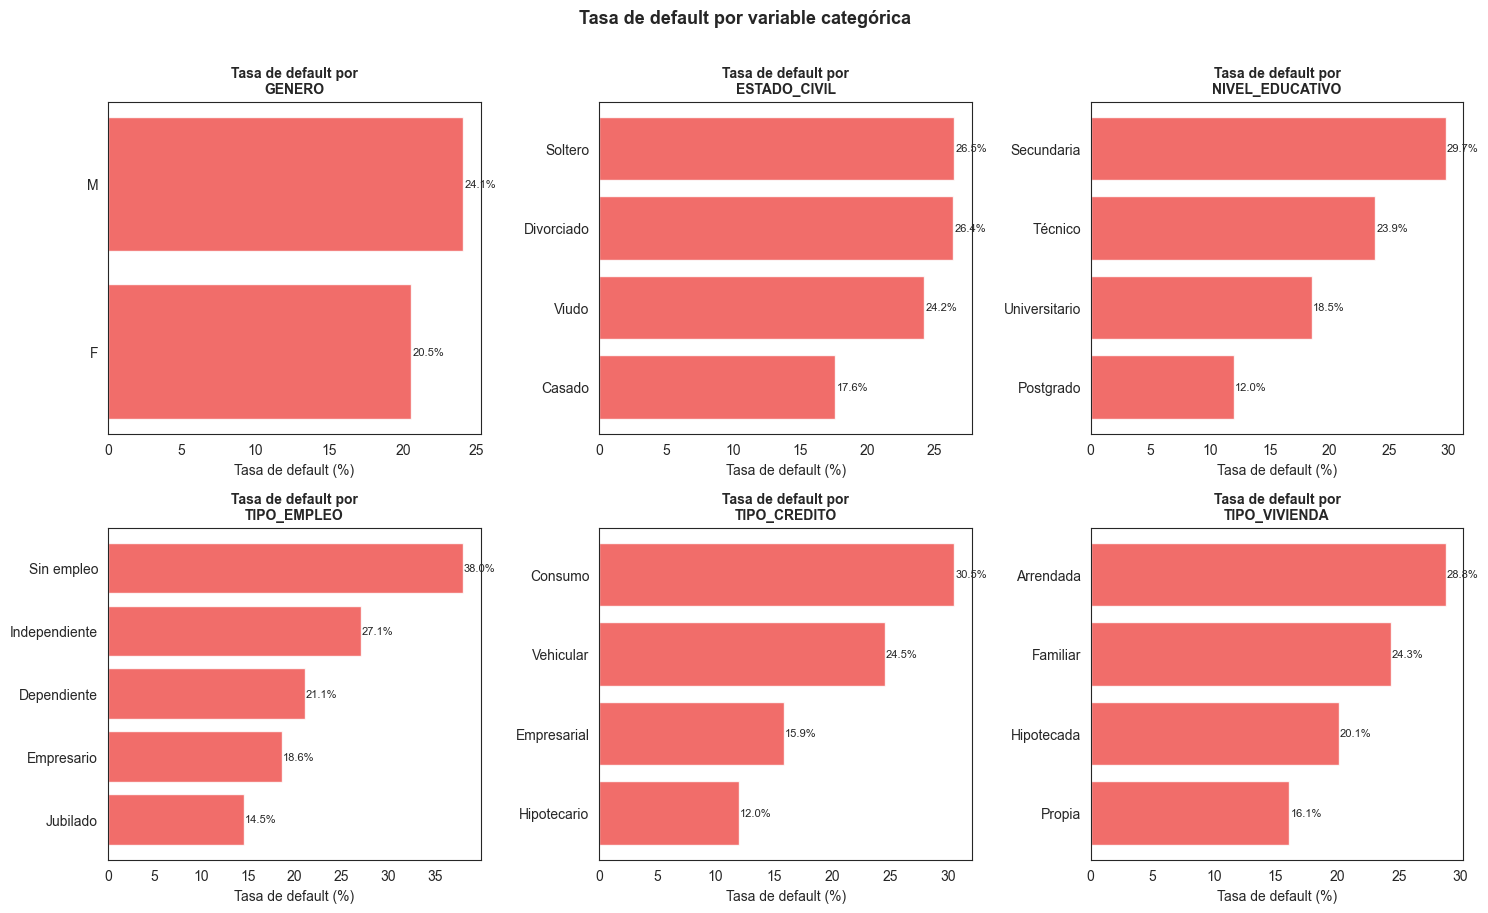

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

df_plot = X_train.copy()
df_plot['DEFAULT'] = y_train.values

for i, col in enumerate(v_cat):
    default_rate = df_plot.groupby(col)['DEFAULT'].mean().sort_values()
    counts_n = df_plot.groupby(col)['DEFAULT'].count()
    
    bars = axes[i].barh(default_rate.index, default_rate.values * 100,
                         color='#EF5350', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Tasa de default por\n{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Tasa de default (%)')
    for bar, val in zip(bars, default_rate.values):
        axes[i].text(val * 100 + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center', fontsize=8)

plt.suptitle('Tasa de default por variable categórica', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# ── 1. ESTADO_CIVIL → Binaria ─────────────────────────────
X_train['CASADO'] = (X_train['ESTADO_CIVIL'] == 'Casado').astype(int)

X_train.drop(columns=['ESTADO_CIVIL'], inplace=True)

# ── 2. NIVEL_EDUCATIVO → Ordinal ──────────────────────────
map_educ = {
    'Secundaria': 3,
    'Técnico': 2,
    'Universitario': 1,
    'Postgrado': 0
}

X_train['NIVEL_EDUCATIVO'] = X_train['NIVEL_EDUCATIVO'].map(map_educ)

# ── 3. TIPO_EMPLEO → Ordinal ──────────────────────────────
map_empleo = {
    'Sin empleo': 4,
    'Independiente': 3,
    'Dependiente': 2,
    'Empresario': 1,
    'Jubilado': 0
}

X_train['TIPO_EMPLEO'] = X_train['TIPO_EMPLEO'].map(map_empleo)

# ── 4. TIPO_CREDITO → Ordinal ─────────────────────────────
map_credito = {
    'Consumo': 3,
    'Vehicular': 2,
    'Empresarial': 1,
    'Hipotecario': 0
}

X_train['TIPO_CREDITO'] = X_train['TIPO_CREDITO'].map(map_credito)

# ── 5. TIPO_VIVIENDA → Ordinal ────────────────────────────
map_vivienda = {
    'Arrendada': 3,
    'Familiar': 2,
    'Hipotecada': 1,
    'Propia': 0
}

X_train['TIPO_VIVIENDA'] = X_train['TIPO_VIVIENDA'].map(map_vivienda)

# ── 6. GENERO → Binaria ───────────────────────────────────
X_train['GENERO'] = (X_train['GENERO'] == 'M').astype(int)

# 📐 **6: Tratamiento de Outliers**

Diferencia con el enfoque clásico (WOE/IV)

En la Sesión 3 (Parte 1), tratamos outliers con winsorización antes del binning para WOE. En ML, el impacto de los outliers depende del algoritmo:

| Algoritmo | Sensibilidad a outliers | Acción recomendada |
|-----------|-------------------------|--------------------|
| **Regresión Logística** | Alta | Winsorizar o aplicar log |
| **Árbol de Decisión** | Baja (usa splits) | Generalmente no necesario |
| **Random Forest** | Baja | Generalmente no necesario |
| **XGBoost / LightGBM** | Baja | Opcional |
| **Redes Neuronales** | Alta | Escalar + winsorizar |

> 📌 **Estrategia del curso:** Aplicamos una transformación log para variables con distribución muy sesgada (ingresos, montos) y winsorización al percentil 1–99 para el resto. Esto favorece la Regresión Logística de la Sesión 9 y no perjudica los árboles.

In [21]:
def detectar_outliers(df, columnas):
    resultados = []
    
    for col in columnas:
        if df[col].dtype == 'object':
            continue
        
        p1 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        
        n_out = ((df[col] < p1) | (df[col] > p99)).sum()
        
        resultados.append({
            'Variable': col,
            'P1': p1,
            'P99': p99,
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Outliers': n_out,
            'Outliers (%)': n_out / len(df) * 100
        })
    
    return pd.DataFrame(resultados).sort_values('Outliers (%)', ascending=False)

outlier_summary = detectar_outliers(X_train, X_train.columns)
outlier_summary

,Variable,P1,P99,Min,Max,Outliers,Outliers (%)
13,RATIO_UTILIZACION,0.02594,0.70308,0.0011,0.9126,348,2.006805
8,MONTO_CREDITO,1264.40000,136729.40000,1000.0000,300000.0000,348,2.006805
5,INGRESO_MENSUAL,595.40000,10111.60000,500.0000,25908.0000,348,2.006805
6,ANTIGUEDAD_LABORAL,0.10000,32.10000,0.0000,40.0000,285,1.643504
10,TASA_INTERES,5.00000,31.84000,5.0000,40.9600,173,0.997636
15,RATIO_LTV,0.00000,0.93400,0.0000,0.9500,171,0.986102
0,EDAD,18.00000,67.00000,18.0000,75.0000,153,0.882302
11,NUM_CREDITOS_PREVIOS,0.00000,8.00000,0.0000,11.0000,70,0.403668
1,GENERO,0.00000,1.00000,0.0000,1.0000,0,0.000000
2,NIVEL_EDUCATIVO,0.00000,3.00000,0.0000,3.0000,0,0.000000


In [22]:
# ── Winsorización (percentil 1–99) para variables con outliers importantes ─────
VARS_WINSORIZACION = ['RATIO_UTILIZACION']
for col in VARS_WINSORIZACION:
    p1_train = X_train[col].quantile(0.01)
    p99_train = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower=p1_train, upper=p99_train)
    print(f'  Winsorizado: {col} → [{p1_train:.2f}, {p99_train:.2f}]')

print(f'\nTratamiento de outliers completado.')
print(f'   Shape actual: {X_train.shape}')

  Winsorizado: RATIO_UTILIZACION → [0.03, 0.70]

Tratamiento de outliers completado.
   Shape actual: (17341, 19)


# 🛠️ **7: Feature Engineering para Credit Scoring**

**¿Por qué Feature Engineering en credit scoring ML?**

A diferencia del enfoque WOE/IV (Sesión 4) donde la transformación captura la relación con el target de forma automática, en ML podemos **construir explícitamente** variables que:
- Capturan **interacciones económicas** entre variables existentes
- Expresan **ratios financieros** de uso estándar en la industria bancaria
- Añaden **señales de comportamiento** que no existen de forma directa en los datos

**Regla de oro:** Crear pocos features pero con fuerte justificación de negocio. Un feature sin interpretación económica es difícil de defender ante un comité de riesgo o regulador.

**Features que crearemos**

| Feature | Fórmula | Interpretación de negocio |
|---------|---------|---------------------------|
| `CUOTA_ESTIMADA` | `MONTO × TASA / PLAZO` | Carga mensual aproximada del crédito |
| `RATIO_ENDEUDAMIENTO` | `CUOTA / INGRESO` | % del ingreso comprometido en la cuota (DTI proxy) |
| `SEGMENTO_RIESGO` | Binning de `RATIO_ENDEUDAMIENTO` | Segmentación de riesgo por carga financiera |
| `INTERACCION_EDAD_MORA` | `EDAD × DIAS_MORA_MAX` | Captura si la mora es más grave en clientes jóvenes |
| `LOG` | `Trans Logaritmo` | Suavizar variables monetarias |


> **Advertencia de data leakage:** Todos estos features deben calcularse con información disponible al momento de la solicitud. Variables como el saldo final del crédito o el número de cuotas pagadas son información futura y están prohibidas.

In [23]:
X_train.head()

,EDAD,GENERO,NIVEL_EDUCATIVO,NUM_DEPENDIENTES,TIPO_EMPLEO,INGRESO_MENSUAL,ANTIGUEDAD_LABORAL,TIPO_CREDITO,MONTO_CREDITO,PLAZO_MESES,TASA_INTERES,NUM_CREDITOS_PREVIOS,DIAS_MORA_MAX,RATIO_UTILIZACION,TIPO_VIVIENDA,RATIO_LTV,IND_INGRESO_MISSING,IND_HISTORIAL_MISSING,CASADO
55,52,1,0,2,3,3279.0,10.0,3,6503.0,84,17.93,3,30.0,0.1972,3,0.000,1,0,0
533,28,1,2,1,2,3152.0,1.7,0,5988.0,84,18.88,2,0.0,0.1604,0,0.642,0,1,1
1856,57,0,1,0,2,3181.0,0.5,0,9853.0,48,21.63,5,0.0,0.2798,2,0.821,0,0,0
2829,37,1,2,0,3,1233.0,12.4,0,22521.0,36,11.02,2,90.0,0.3468,0,0.622,0,0,1
3486,58,0,2,0,1,1470.0,8.3,3,13057.0,24,16.96,4,0.0,0.1068,3,0.000,0,0,1


In [24]:
# ── 1. CUOTA_ESTIMADA ────────────────────────────────────────────────
tasa_mensual = (X_train['TASA_INTERES'] / 100) / 12
n = X_train['PLAZO_MESES']
P = X_train['MONTO_CREDITO']

cuota = np.where(
    tasa_mensual > 0,
    P * tasa_mensual / (1 - (1 + tasa_mensual) ** (-n)),
    P / n
)
X_train['CUOTA_ESTIMADA'] = cuota.round(2)

# ── 2. RATIO_ENDEUDAMIENTO ──────────────────────────────────────────
X_train['RATIO_ENDEUDAMIENTO'] = (
    X_train['CUOTA_ESTIMADA'] / X_train['INGRESO_MENSUAL'].replace(0, np.nan)
).clip(0, 5).fillna(
    X_train['CUOTA_ESTIMADA'] / X_train['INGRESO_MENSUAL'].median()
).round(4)

# ── 3. SEGMENTO_RIESGO (numérico, no string) ─────────────────────────
X_train['SEGMENTO_RIESGO'] = pd.cut(
    X_train['RATIO_ENDEUDAMIENTO'],
    bins=[-np.inf, 0.20, 0.35, 0.50, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

# ── 4. INTERACCION_EDAD_MORA ────────────────────────────────────────
X_train['INTERACCION_EDAD_MORA'] = (
    (1 / X_train['EDAD'].clip(18, 75)) * X_train['DIAS_MORA_MAX']
).round(6)

# ── 5. LOG TRANSFORM ────────────────────────────────────────────────
VARS_LOG_TRANSFORM = ['INGRESO_MENSUAL', 'MONTO_CREDITO']

for col in VARS_LOG_TRANSFORM:
    X_train[f'LOG_{col}'] = np.log1p(X_train[col])
    X_train.drop(columns=col, inplace=True)
    print(f'  Creada: LOG_{col}')

# ── Resumen ─────────────────────────────────────────────────────────
nuevos_features = [
    'CUOTA_ESTIMADA',
    'RATIO_ENDEUDAMIENTO',
    'SEGMENTO_RIESGO',
    'INTERACCION_EDAD_MORA'
]

print(f'\nFeature Engineering completado: {len(nuevos_features)} nuevas variables creadas')
print(f'Shape: {X_train.shape}')

print(f'\nNuevos features:')
for f in nuevos_features:
    print(f'  {f}: {X_train[f].dtype} | rango [{X_train[f].min():.3f}, {X_train[f].max():.3f}]')

  Creada: LOG_INGRESO_MENSUAL
  Creada: LOG_MONTO_CREDITO

Feature Engineering completado: 4 nuevas variables creadas
Shape: (17341, 23)

Nuevos features:
  CUOTA_ESTIMADA: float64 | rango [13.390, 23045.350]
  RATIO_ENDEUDAMIENTO: float64 | rango [0.003, 5.000]
  SEGMENTO_RIESGO: int64 | rango [0.000, 3.000]
  INTERACCION_EDAD_MORA: float64 | rango [0.000, 10.000]


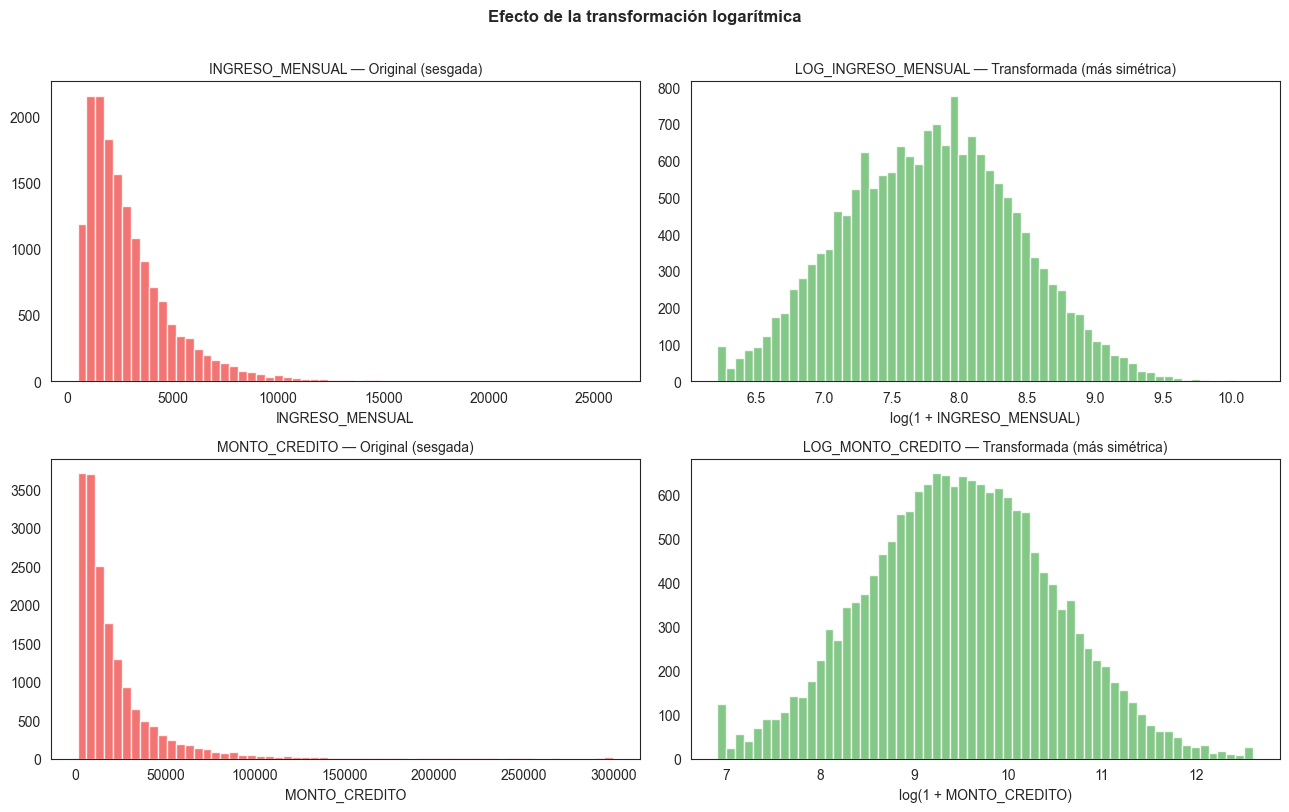

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for idx, col in enumerate(VARS_LOG_TRANSFORM):
    row = idx
    # Antes
    axes[row, 0].hist(train[col], bins=60, color='#EF5350', edgecolor='white', alpha=0.8)
    axes[row, 0].set_title(f'{col} — Original (sesgada)', fontsize=10)
    axes[row, 0].set_xlabel(col)
    # Después
    axes[row, 1].hist(X_train[f'LOG_{col}'], bins=60, color='#66BB6A', edgecolor='white', alpha=0.8)
    axes[row, 1].set_title(f'LOG_{col} — Transformada (más simétrica)', fontsize=10)
    axes[row, 1].set_xlabel(f'log(1 + {col})')

plt.suptitle('Efecto de la transformación logarítmica', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ⚖️ **8: Escalado y Transformación de Variables Numéricas**

¿Cuándo escalar en credit scoring ML?

| Algoritmo | ¿Requiere escalado? | Escalador recomendado |
|-----------|---------------------|----------------------|
| Regresión Logística | ✅ Sí | StandardScaler |
| SVM | ✅ Sí | StandardScaler |
| KNN | ✅ Sí | MinMaxScaler |
| Árboles de Decisión | ❌ No | — |
| Random Forest | ❌ No | — |
| XGBoost / LightGBM | ❌ No | — |
| Redes Neuronales | ✅ Sí | MinMaxScaler o StandardScaler |

> ⚠️ **Regla crítica:** El escalador se ajusta **SOLO** en el conjunto de entrenamiento y luego se aplica (transform) al conjunto de validación y test. Ajustar en el dataset completo introduce *data leakage*.

In [26]:
# ── 1. Definir columnas que NO se escalan ────────────────────────────
cols_no_escalar = [
    'GENERO',
    'CASADO',
    'IND_INGRESO_MISSING',
    'IND_HISTORIAL_MISSING',
    'SEGMENTO_RIESGO',
    'TIPO_EMPLEO',
    'TIPO_CREDITO',
    'TIPO_VIVIENDA',
    'NIVEL_EDUCATIVO'
]

# ── 2. Definir columnas a escalar ────────────────────────────────────
num_cols = [col for col in X_train.columns if col not in cols_no_escalar]

print(f'Columnas a escalar ({len(num_cols)}):')
print(num_cols)

# ── 3. Inicializar scaler ────────────────────────────────────────────
scaler = StandardScaler()

# ── 4. Fit SOLO en TRAIN ─────────────────────────────────────────────
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
print('\nShapes finales:')
print(f'X_train: {X_train.shape}')

Columnas a escalar (14):
['EDAD', 'NUM_DEPENDIENTES', 'ANTIGUEDAD_LABORAL', 'PLAZO_MESES', 'TASA_INTERES', 'NUM_CREDITOS_PREVIOS', 'DIAS_MORA_MAX', 'RATIO_UTILIZACION', 'RATIO_LTV', 'CUOTA_ESTIMADA', 'RATIO_ENDEUDAMIENTO', 'INTERACCION_EDAD_MORA', 'LOG_INGRESO_MENSUAL', 'LOG_MONTO_CREDITO']

Shapes finales:
X_train: (17341, 23)


# 📌 **9: Manejo del Desbalance de Clases**

En credit scoring real, la tasa de default típicamente oscila entre **3%–15%**. Este desbalance puede causar que los modelos ML optimicen accuracy prediciendo siempre la clase mayoritaria ("nunca hay default"), obteniendo alta accuracy pero nula utilidad.

### Técnicas disponibles

| Técnica | Tipo | Descripción | Cuándo usar |
|---------|------|-------------|-------------|
| **class_weight='balanced'** | Pesos | Ajusta pesos en la función de pérdida | Modelo ya lo soporta (sklearn) |
| **SMOTE** | Oversampling | Genera sintéticamente samples de la minoría | Desbalance moderado (<20:1) |
| **Random Undersampling** | Undersampling | Reduce muestras de la mayoría | Dataset grande |

> **Recomendación para credit scoring bancario:** Preferir `class_weight='balanced'` o ajuste de umbral. SMOTE puede generar observaciones sintéticas que no corresponden a perfiles reales de clientes (importante para auditabilidad regulatoria).

In [27]:
y_train.value_counts()

DEFAULT
0    13460
1     3881
Name: count, dtype: int64

In [28]:
# ── Demostración de SMOTE ─────────────────────────────────────────────────────
print('Distribución ORIGINAL en train:')
print(y_train.value_counts())
print(f'  Ratio: {y_train.mean()}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nDistribución después de SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'  Ratio: {pd.Series(y_train_sm).mean()}')
print(f'\n  SMOTE generó {len(X_train_sm) - len(X_train):,} nuevas observaciones sintéticas')

Distribución ORIGINAL en train:
DEFAULT
0    13460
1     3881
Name: count, dtype: int64
  Ratio: 0.22380485554466295

Distribución después de SMOTE:
DEFAULT
0    13460
1    13460
Name: count, dtype: int64
  Ratio: 0.5

  SMOTE generó 9,579 nuevas observaciones sintéticas
